In [2]:
#import the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#read the excel file

In [5]:
df = pd.read_excel('ABC Company.xlsx')
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,2023-03-06 00:00:00,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,2023-01-06 00:00:00,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,2023-03-07 00:00:00,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [6]:
print(df.head())

            Name            Team  Number Position  Age               Height  \
0  Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1    Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2   John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3    R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4  Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   

   Weight            College     Salary  
0     180              Texas  7730337.0  
1     235          Marquette  6796117.0  
2     205  Boston University        NaN  
3     185      Georgia State  1148640.0  
4     231                NaN  5000000.0  


In [7]:
print(df.shape)

(458, 9)


In [8]:
print(df.columns)

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')


In [9]:
print(df.dtypes)

Name         object
Team         object
Number        int64
Position     object
Age           int64
Height       object
Weight        int64
College      object
Salary      float64
dtype: object


In [10]:
#to check missing values

In [11]:
print(df.isnull().sum())

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64


Preprocessing

1. Correct the data in the "height" column by replacing it with random numbers between 150 and 180.

In [13]:
df["Height"] = np.random.randint(150,181,size=len(df))

In [14]:
print(df["Height"])

0      154
1      157
2      177
3      160
4      179
      ... 
453    174
454    171
455    169
456    152
457    165
Name: Height, Length: 458, dtype: int32


In [15]:
#Analysis Tasks

1. Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees. 

In [16]:
team_count = df["Team"].value_counts()
print(team_count)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


In [17]:
team_percentage = df["Team"].value_counts(normalize=True) * 100
print(team_percentage)

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

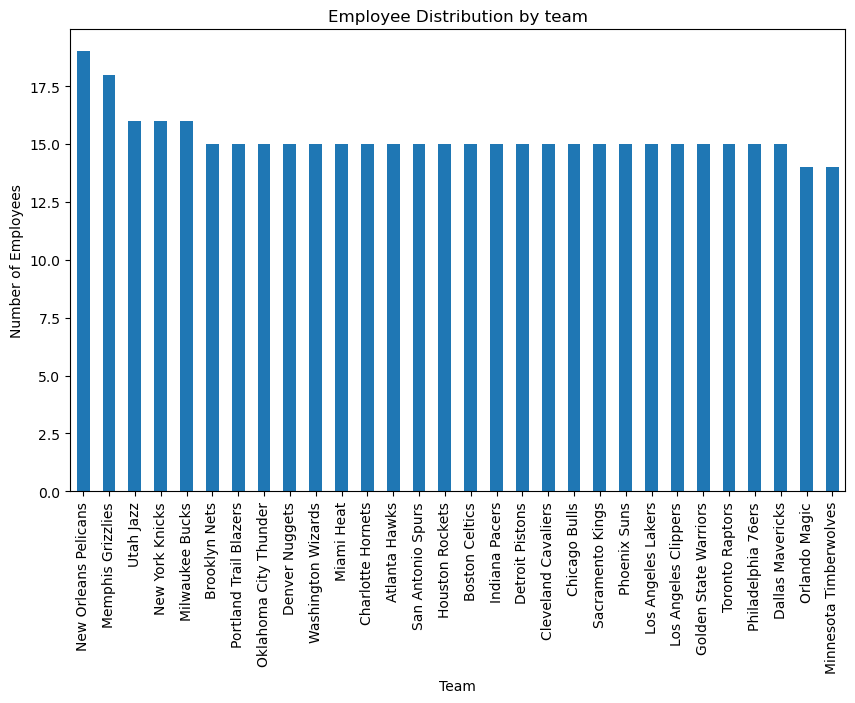

In [37]:
plt.figure(figsize=(10,6))

team_count.plot(kind="bar")

plt.title("Employee Distribution by team")
plt.xlabel("Team")
plt.ylabel("Number of Employees")

plt.show()

2. Segregate employees based on their positions within the company.

In [23]:
position_count = df["Position"].value_counts()
print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


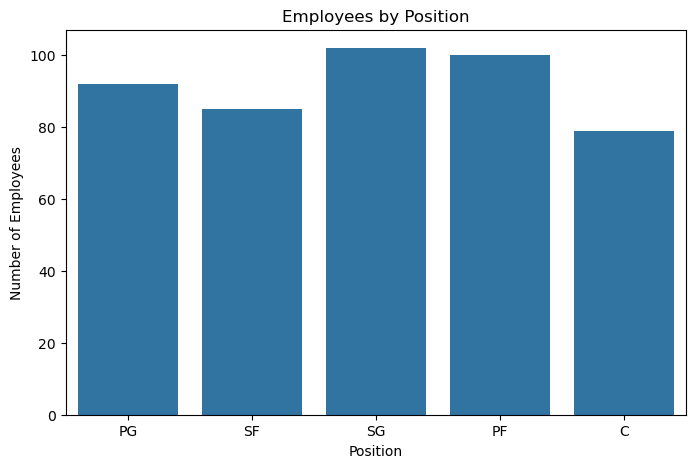

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Position")

plt.title("Employees by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")

plt.show()

3. Identify the predominant age group among employees.

In [25]:
bins = [17, 25, 35, 45, 55, 100]

labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [26]:
age_group_count = df["Age_Group"].value_counts()
print(age_group_count)

Age_Group
26-35    235
18-25    200
36-45     23
46-55      0
56+        0
Name: count, dtype: int64


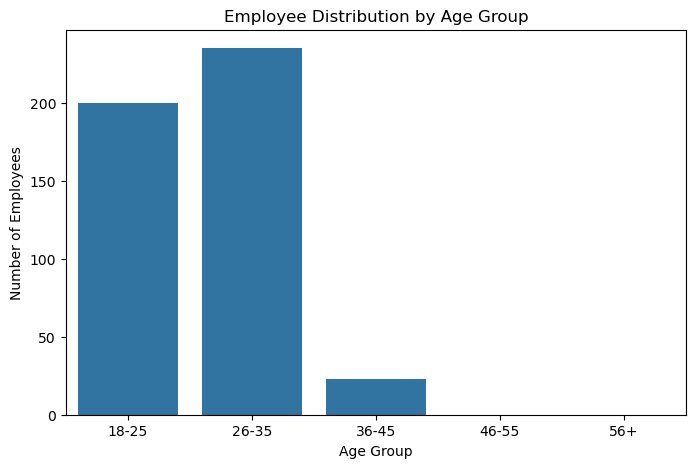

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Age_Group")

plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

4. Discover which team and position have the highest salary expenditure.

In [30]:
team_salary = df.groupby("Team")["Salary"].sum()
print(team_salary)

Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings           71683666.0
San Ant

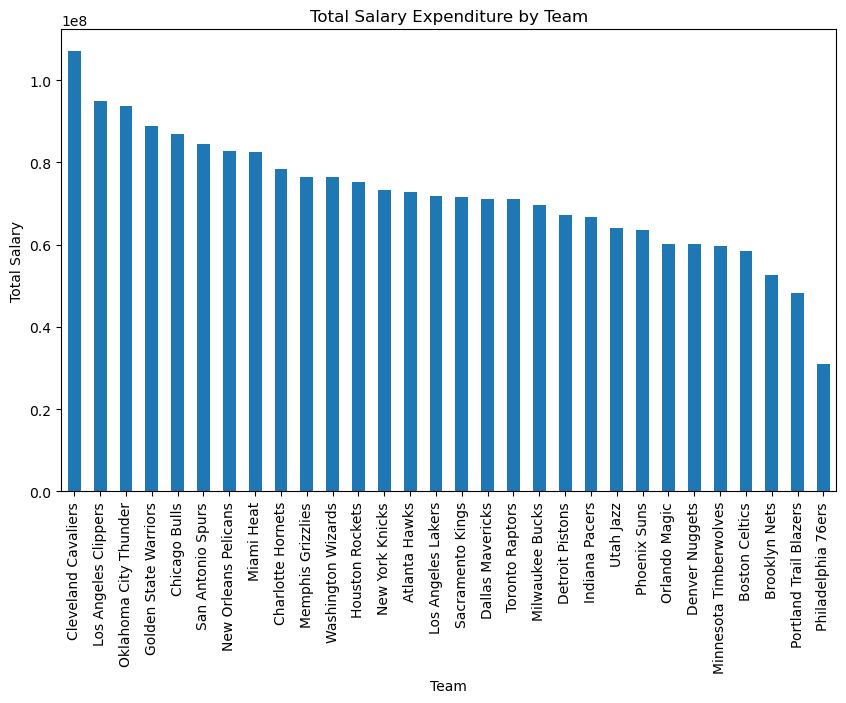

In [31]:
plt.figure(figsize=(10, 6))

team_salary.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")

plt.show()

In [32]:
position_salary = df.groupby("Position")["Salary"].sum()
print(position_salary)

Position
C     466377332.0
PF    442560850.0
PG    446848971.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64


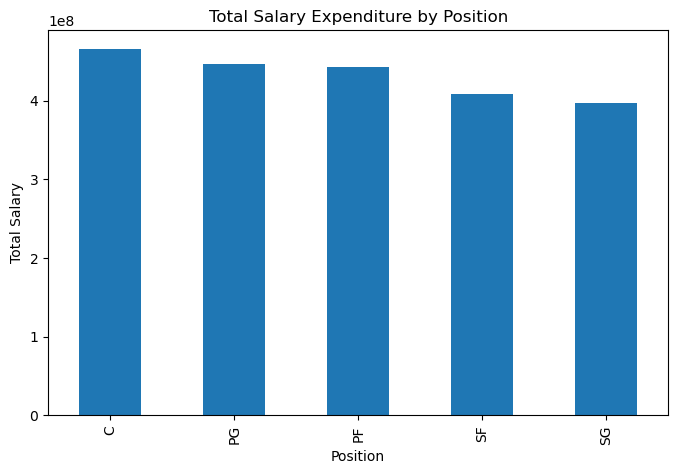

In [33]:
plt.figure(figsize=(8, 5))

position_salary.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")

plt.show()

In [34]:
print("Highest salary expenditure team:", team_salary.idxmax())
print("Highest salary expenditure position:", position_salary.idxmax())

Highest salary expenditure team: Cleveland Cavaliers
Highest salary expenditure position: C


5. Investigate if there's any correlation between age and salary, and
represent it visually.

In [35]:
correlation = df["Age"].corr(df["Salary"])
print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.21400941226570985


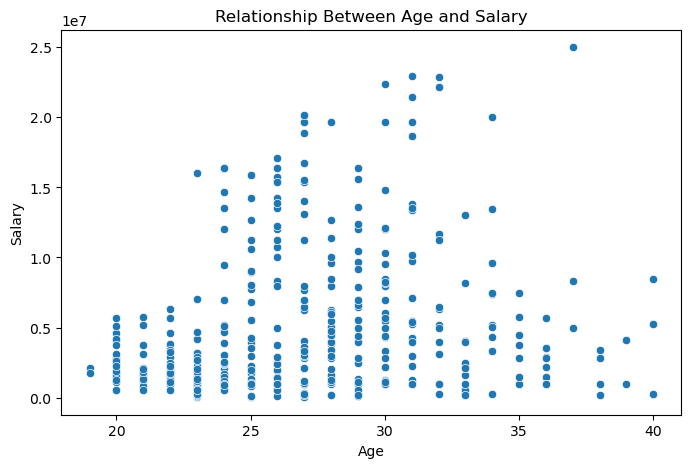

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Age", y="Salary")

plt.title("Relationship Between Age and Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

DATA STORY

The analysis shows that employees are fairly distributed across teams, with the New Orleans Pelicans having the most employees. Shooting Guard is the most common position. The 26–35 age group is predominant, indicating a young workforce. The Cleveland Cavaliers have the highest salary expenditure among teams, while Center has the highest expenditure by position. Age and salary show a weak positive correlation (0.21), suggesting age has limited influence on salary.